**1. Tratar valores nulos segun su mecanismo (MCAR, MAR,MNAR):**

*   Imputacion por media/mediana/moda.
*   KNNImputer, IterativeImputer

*Separar tipos de variables*

In [39]:
import pandas as pd


DATA_PATH = "../data/raw/06-kickAutomotriz.csv"

df = pd.read_csv(DATA_PATH)
display(df.head())
# Numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categóricas
cat_cols = df.select_dtypes(include=['object']).columns

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,1260144000,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,0,1260144000,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,0,1260144000,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,0,1260144000,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,SILVER,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,0,1260144000,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


Numéricas: Index(['IsBadBuy', 'PurchDate', 'VehYear', 'VehicleAge', 'WheelTypeID',
       'VehOdo', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice', 'BYRNO', 'VNZIP1', 'VehBCost',
       'IsOnlineSale', 'WarrantyCost'],
      dtype='str')
Categóricas: Index(['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission',
       'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT',
       'AUCGUART', 'VNST'],
      dtype='str')


C:\Users\PONCE\AppData\Local\Temp\ipykernel_21832\2674356358.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


*`Convertir fecha correctamente`*

In [40]:
df['PurchDate'] = pd.to_datetime(df['PurchDate'])

Re-definir variables correctamente

In [41]:
# Variables numéricas reales
num_cols = [
    'VehYear', 'VehicleAge', 'VehOdo',
    'MMRAcquisitionAuctionAveragePrice',
    'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice',
    'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionAveragePrice',
    'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice',
    'MMRCurrentRetailCleanPrice',
    'VehBCost',
    'WarrantyCost'
]

# Variables categóricas (incluyendo IDs)
cat_cols = [
    'Auction', 'Make', 'Model', 'Trim', 'SubModel',
    'Color', 'Transmission', 'WheelType',
    'Nationality', 'Size', 'TopThreeAmericanName',
    'PRIMEUNIT', 'AUCGUART', 'VNST',
    'BYRNO', 'VNZIP1', 'WheelTypeID'
]

*Imputación simple (MCAR)*

In [42]:
from sklearn.impute import SimpleImputer

simple_cols = ['VehYear', 'VehicleAge', 'VehOdo', 'WarrantyCost']

imputer_median = SimpleImputer(strategy='median')
df[simple_cols] = imputer_median.fit_transform(df[simple_cols])

*Numéricas complejas (MAR → KNN)*

In [43]:
from sklearn.impute import KNNImputer

knn_cols = [
    'MMRAcquisitionAuctionAveragePrice',
    'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice',
    'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionAveragePrice',
    'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice',
    'MMRCurrentRetailCleanPrice',
    'VehBCost'
]

imputer_knn = KNNImputer(n_neighbors=5)
df[knn_cols] = imputer_knn.fit_transform(df[knn_cols])

*Categóricas (moda)*

In [44]:
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

*Convierte la fecha en variables útiles:*

In [45]:
df['year'] = df['PurchDate'].dt.year
df['month'] = df['PurchDate'].dt.month

**2. Detectar y tratar outliers (IQR, z-score, winsorizing)**

*¿En qué variables buscar outliers?*

In [46]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
                (df[num_cols] > (Q3 + 1.5 * IQR)))

print(outliers_iqr.sum())

VehYear                                 0
VehicleAge                            646
VehOdo                                336
MMRAcquisitionAuctionAveragePrice     522
MMRAcquisitionAuctionCleanPrice       841
MMRAcquisitionRetailAveragePrice      317
MMRAcquisitonRetailCleanPrice        1261
MMRCurrentAuctionAveragePrice         572
MMRCurrentAuctionCleanPrice          1334
MMRCurrentRetailAveragePrice          295
MMRCurrentRetailCleanPrice            930
VehBCost                              187
WarrantyCost                          838
dtype: int64


Muchos outliers en:

*   MMRCurrentAuctionCleanPrice → 1334
*   MMRAcquisitonRetailCleanPrice → 1261
*   WarrantyCost → 838

*Aplicar clipping (winsorizing con IQR)*

In [47]:
df_out = df.copy()

for col in num_cols:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_out[col] = df_out[col].clip(lower, upper)

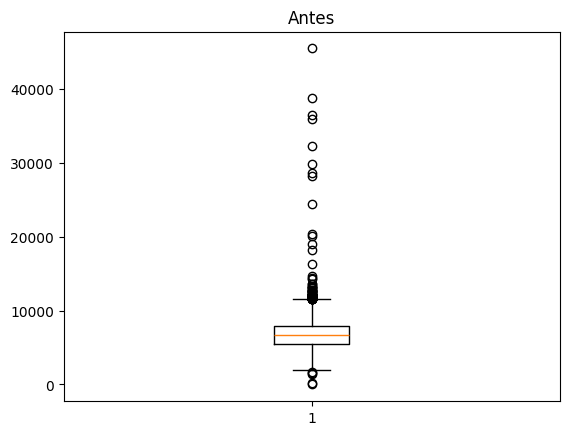

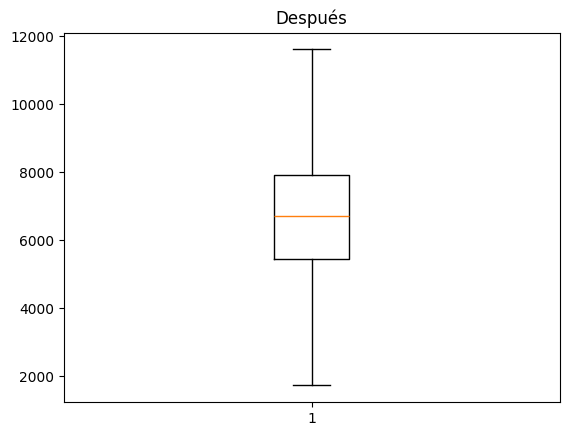

In [48]:
import matplotlib.pyplot as plt

plt.boxplot(df['VehBCost'])
plt.title("Antes")
plt.show()

plt.boxplot(df_out['VehBCost'])
plt.title("Después")
plt.show()

Detección correcta de outliers con IQR
 

*   No se eliminó datos (decisión correcta)
*   Se Aplicó winsorizing para mantener robustez del modelo

**3. Eliminar duplicados y registros inconsistentes**

In [49]:
# Número de duplicados exactos
print("Duplicados totales:", df.duplicated().sum())

# Verlos
df[df.duplicated()]

Duplicados totales: 0


,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,year,month


In [50]:
df.duplicated(subset=['Make', 'Model', 'VehYear', 'VehOdo']).sum()

np.int64(213)

In [51]:
df[df.duplicated(subset=['Make', 'Model', 'VehYear', 'VehOdo'], keep=False)].head(10)

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,year,month
106,0,1970-01-01 00:00:01.266192000,ADESA,2005.0,5.0,CHEVROLET,IMPALA,Bas,4D SEDAN,SILVER,...,NO,GREEN,5546,33619,FL,5900.0,0,2152.0,1970,1
182,0,1970-01-01 00:00:01.269820800,ADESA,2006.0,4.0,PONTIAC,G6 V6,Bas,4D SEDAN,SILVER,...,NO,GREEN,19619,33619,FL,7400.0,0,1118.0,1970,1
427,0,1970-01-01 00:00:01.234915200,ADESA,2005.0,4.0,CHRYSLER,PACIFICA FWD 3.5L V6,Tou,4D SPORT,WHITE,...,NO,GREEN,20740,20166,VA,7825.0,0,1215.0,1970,1
454,0,1970-01-01 00:00:01.251244800,ADESA,2006.0,3.0,CHRYSLER,SEBRING 4C 2.4L I4 S,Bas,4D SEDAN,BLACK,...,NO,GREEN,20740,20166,VA,4565.0,0,1155.0,1970,1
970,1,1970-01-01 00:00:01.265673600,ADESA,2006.0,4.0,DODGE,CARAVAN GRAND FWD V6,Bas,MINIVAN 3.3L,RED,...,NO,GREEN,22916,50111,IA,7525.0,0,1411.0,1970,1
1173,0,1970-01-01 00:00:01.288051200,ADESA,2008.0,2.0,CHEVROLET,IMPALA V6,LS,4D SEDAN LS 3.5L FFV,GREY,...,NO,GREEN,3453,55369,MN,8435.0,0,1974.0,1970,1
1416,0,1970-01-01 00:00:01.259798400,ADESA,2007.0,2.0,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,GREY,...,NO,GREEN,11410,17406,PA,6525.0,1,1038.0,1970,1
1517,1,1970-01-01 00:00:01.286323200,ADESA,2006.0,4.0,CHEVROLET,COBALT,LS,4D SEDAN LS,RED,...,NO,GREEN,52117,17406,PA,4815.0,0,853.0,1970,1
1651,0,1970-01-01 00:00:01.274400000,ADESA,2005.0,5.0,NISSAN,ALTIMA,Bas,4D SEDAN,WHITE,...,NO,GREEN,5546,34203,FL,7675.0,0,723.0,1970,1
1737,0,1970-01-01 00:00:01.282867200,ADESA,2006.0,4.0,CHRYSLER,PT CRUISER,Bas,4D SEDAN,SILVER,...,NO,GREEN,5546,34203,FL,5055.0,0,1215.0,1970,1


*Eliminación de duplicados:*

No se encontraron registros completamente duplicados.
Se detectaron 213 posibles duplicados basados en variables (Make, Model, VehYear, VehOdo).
Sin embargo, estos no fueron eliminados, ya que representan vehículos distintos con características similares.
Se decidió conservarlos para no perder información relevante.

In [52]:
# Valores inválidos
print("VehOdo <= 0:", (df['VehOdo'] <= 0).sum())
print("VehBCost <= 0:", (df['VehBCost'] <= 0).sum())
print("VehYear raro:", ((df['VehYear'] < 1980) | (df['VehYear'] > 2026)).sum())

VehOdo <= 0: 0
VehBCost <= 0: 0
VehYear raro: 0


*   No hay valores imposibles
*   No hay errores evidentes
*   Dataset consistente en variables clave

In [53]:
df['edad_calculada'] = 2026 - df['VehYear']

# Ver inconsistencias
(df['edad_calculada'] != df['VehicleAge']).sum()

np.int64(72983)

In [54]:
df['VehicleAge'] = df['PurchDate'].dt.year - df['VehYear']

In [55]:
df['edad_calculada'] = df['PurchDate'].dt.year - df['VehYear']

(df['edad_calculada'] != df['VehicleAge']).sum()

np.int64(0)

*Consistencia de variables:*

Se detectaron inconsistencias significativas entre VehicleAge y VehYear.
Se identificó que VehicleAge no era confiable.
Se recalculó utilizando la diferencia entre el año de compra (PurchDate) y el año del vehículo (VehYear).
Posteriormente, se verificó que no existan inconsistencias (0 registros).

**4. Corregir tipos de datos (fechas, categoricos, numéricos).**

In [56]:
df['PurchDate'] = pd.to_datetime(df['PurchDate'])

In [57]:
cat_cols = [
    'Auction', 'Make', 'Model', 'Trim', 'SubModel',
    'Color', 'Transmission', 'WheelType',
    'Nationality', 'Size', 'TopThreeAmericanName',
    'PRIMEUNIT', 'AUCGUART', 'VNST'
]

In [58]:
for col in cat_cols:
    df[col] = df[col].astype('category')

In [59]:
num_cols = [
    'VehYear', 'VehicleAge', 'VehOdo',
    'MMRAcquisitionAuctionAveragePrice',
    'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice',
    'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionAveragePrice',
    'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice',
    'MMRCurrentRetailCleanPrice',
    'VehBCost',
    'WarrantyCost'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [60]:
id_cols = ['BYRNO', 'VNZIP1', 'WheelTypeID']

In [61]:
for col in id_cols:
    df[col] = df[col].astype('category')

In [62]:
binary_cols = ['IsBadBuy', 'IsOnlineSale']

for col in binary_cols:
    df[col] = df[col].astype(int)

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   IsBadBuy                           72983 non-null  int64         
 1   PurchDate                          72983 non-null  datetime64[ns]
 2   VehYear                            72983 non-null  float64       
 3   VehicleAge                         72983 non-null  float64       
 4   Make                               72983 non-null  float64       
 5   Model                              72983 non-null  float64       
 6   Trim                               72983 non-null  float64       
 7   SubModel                           72983 non-null  float64       
 8   WheelTypeID                        72983 non-null  category      
 9   VehOdo                             72983 non-null  float64       
 10  Nationality                        72983 non-

*Corrección de tipos de datos:*

La variable PurchDate fue convertida a formato datetime para permitir análisis temporal.
Las variables categóricas fueron transformadas a tipo category para optimizar memoria y facilitar su posterior codificación.
Se verificó que las variables numéricas estén en formato adecuado (int o float).
Variables identificadoras (BYRNO, VNZIP1, WheelTypeID) fueron tratadas como categóricas.
Variables binarias (IsBadBuy, IsOnlineSale) se mantuvieron como numéricas enteras.

*Archivo Final*

In [75]:
df.to_csv(r"C:\Users\PONCE\dp261-g1\data\interim\cleaned_data.csv", index=False)

*PASO SIGUIENTE*

*-----------------------------------------------------------------------------------------------------------------*

**5. Aplicar encoding a categoricas: OneHot, Ordinal, Target.**

In [64]:
from sklearn.preprocessing import OneHotEncoder

onehot_cols = ['Transmission', 'Color', 'Auction', 'WheelType']

df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

In [65]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['Size']

encoder_ord = OrdinalEncoder()

df[ordinal_cols] = encoder_ord.fit_transform(df[ordinal_cols])

In [66]:
!pip install category_encoders

In [67]:
import category_encoders as ce

target_cols = ['Make', 'Model', 'SubModel', 'Trim', 'VNZIP1', 'BYRNO']

encoder_target = ce.TargetEncoder(cols=target_cols)

df[target_cols] = encoder_target.fit_transform(df[target_cols], df['IsBadBuy'])

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   IsBadBuy                           72983 non-null  int64         
 1   PurchDate                          72983 non-null  datetime64[ns]
 2   VehYear                            72983 non-null  float64       
 3   VehicleAge                         72983 non-null  float64       
 4   Make                               72983 non-null  float64       
 5   Model                              72983 non-null  float64       
 6   Trim                               72983 non-null  float64       
 7   SubModel                           72983 non-null  float64       
 8   WheelTypeID                        72983 non-null  category      
 9   VehOdo                             72983 non-null  float64       
 10  Nationality                        72983 non-

*Encoding de variables categóricas:*

Se aplicó OneHot Encoding a variables con baja cardinalidad (Transmission, Color, Auction, WheelType).
Se utilizó Ordinal Encoding en variables con orden inherente (Size).
Para variables con alta cardinalidad (Make, Model, SubModel, etc.), se aplicó Target Encoding, utilizando la variable objetivo IsBadBuy.
Esta estrategia permite evitar la explosión de dimensiones y mejorar el rendimiento del modelo.

**6. Aplicar escalado: StandardScaler, MinMaxScaler,RobustScaler.**

In [ ]:
scale_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# quitar variables qe no deben escalarse
exclude = ['IsBadBuy', 'VehYear', 'VehicleAge']
scale_cols = [col for col in scale_cols if col not in exclude]

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. Split
X = df.drop('IsBadBuy', axis=1)
y = df['IsBadBuy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Escalado
scaler = RobustScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

*Escalado de variables:*

Se evaluaron distintos métodos de escalado:
StandardScaler: estandariza a media 0 y desviación estándar 1.
MinMaxScaler: escala los valores en un rango entre 0 y 1.
RobustScaler: utiliza la mediana y el rango intercuartil, siendo robusto frente a outliers.
Dado que el dataset presenta valores extremos en variables como precios, se seleccionó RobustScaler como método principal.
El escalado se realizó después de dividir los datos en entrenamiento y prueba, ajustando el scaler únicamente con el conjunto de entrenamiento para evitar data leakage.

In [ ]:
df_clean.to_csv("data/interim/cleaned_data.csv", index=False)